In [1]:
import numpy as np
import pandas as pd

from FeDa4Fair.dataset import FairFederatedDataset


## FairFederatedDataset with Pre-processed dataset

In this example we will see how to use FairFederatedDataset with a dataset that has been pre-processed before being used for federated learning.

In [2]:
print("1. Creating synthetic preloaded data...")

# Let's say we have a dataset with 1000 samples
n_samples = 1000
data = {
    "age": np.random.randint(18, 90, n_samples),
    "income": np.random.normal(50000, 15000, n_samples),
    "education_years": np.random.randint(8, 20, n_samples),
    "gender": np.random.choice(["Male", "Female"], n_samples),
    "label": np.random.randint(0, 2, n_samples) # Binary classification
}
df = pd.DataFrame(data)

1. Creating synthetic preloaded data...


In [3]:
# Preprocessing (e.g., normalization, cleaning) - simplified here
df["income"] = df["income"] / 100000.0

# Split into train/test if you want, or just pass a single "train" split
# Here we simulate having a single "train" dataset that FeDa4Fair will split/partition
preloaded_data = {
    "train": df
}

In [4]:
# 2. Initialize FairFederatedDataset with preloaded_data
print("\n2. Initializing FairFederatedDataset...")
fds = FairFederatedDataset(
    dataset="my_custom_dataset", # Name for the dataset
    preloaded_data=preloaded_data,
    partitioners={"train": 2}, # Split "train" into 2 clients
    label_name="label",
    sensitive_attributes=["gender"],
    fl_setting="cross-silo", # Simulate FL setting to split into train/test per client
)


2. Initializing FairFederatedDataset...


/Users/lucacorbucci/Documents/GitHub/FeDa4Fair/.venv/lib/python3.12/site-packages/flwr_datasets/utils.py:109: UserWarning: The currently tested dataset are ['mnist', 'ylecun/mnist', 'cifar10', 'uoft-cs/cifar10', 'fashion_mnist', 'zalando-datasets/fashion_mnist', 'sasha/dog-food', 'zh-plus/tiny-imagenet', 'scikit-learn/adult-census-income', 'cifar100', 'uoft-cs/cifar100', 'svhn', 'ufldl-stanford/svhn', 'sentiment140', 'stanfordnlp/sentiment140', 'speech_commands', 'LIUM/tedlium', 'flwrlabs/femnist', 'flwrlabs/ucf101', 'flwrlabs/ambient-acoustic-context', 'jlh/uci-mushrooms', 'Mike0307/MNIST-M', 'flwrlabs/usps', 'scikit-learn/iris', 'flwrlabs/pacs', 'flwrlabs/cinic10', 'flwrlabs/caltech101', 'flwrlabs/office-home', 'flwrlabs/fed-isic2019']. Given: my_custom_dataset.
  warnings.warn(



3. Preparing dataset...


Flattening the indices:   0%|          | 0/700 [00:00<?, ? examples/s]

/Users/lucacorbucci/Documents/GitHub/FeDa4Fair/.venv/lib/python3.12/site-packages/flwr_datasets/metrics/utils.py:130: UserWarning: The verbose names can not be established. The column specified by 'column_name' needs to be of type 'ClassLabel' to create a verbose names. The available names will used.
  warnings.warn(


Flattening the indices:   0%|          | 0/150 [00:00<?, ? examples/s]

/Users/lucacorbucci/Documents/GitHub/FeDa4Fair/.venv/lib/python3.12/site-packages/flwr_datasets/metrics/utils.py:130: UserWarning: The verbose names can not be established. The column specified by 'column_name' needs to be of type 'ClassLabel' to create a verbose names. The available names will used.
  warnings.warn(


Flattening the indices:   0%|          | 0/150 [00:00<?, ? examples/s]

/Users/lucacorbucci/Documents/GitHub/FeDa4Fair/src/FeDa4Fair/dataset/fair_dataset.py:213: UserWarning: Your current data contains columns with sensitive attributes. If these should not be in the training data later, please remove them before training.
  self._prepare_dataset()


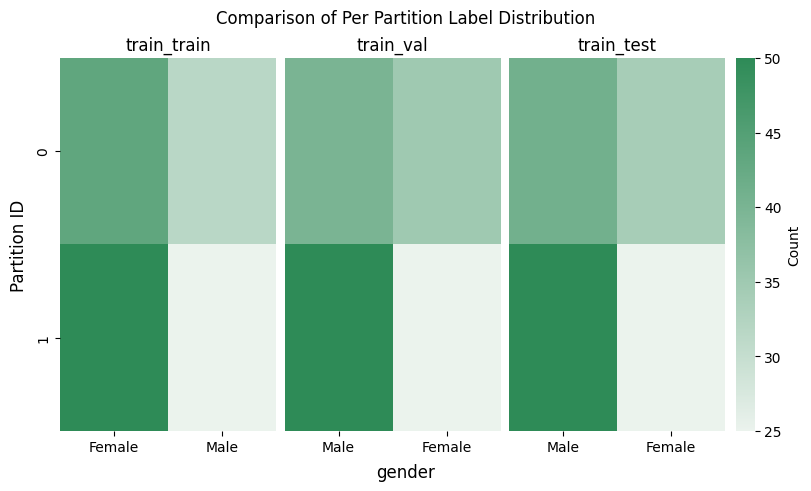

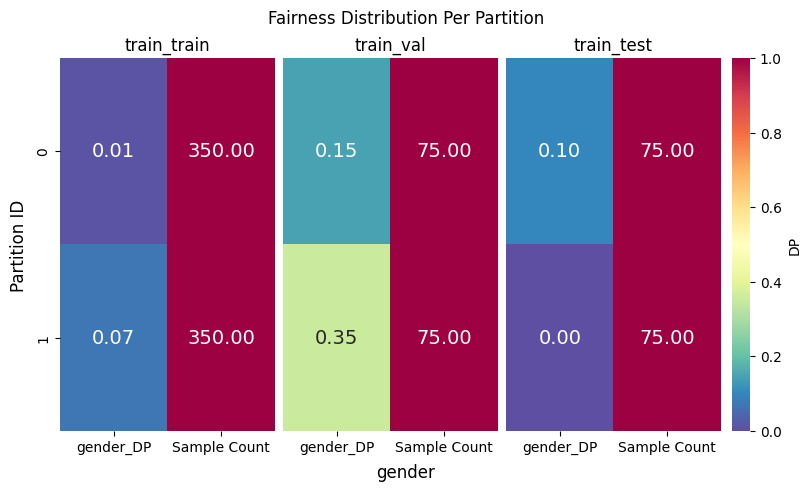

In [5]:
# 3. Prepare the dataset (this will partition the data)
print("\n3. Preparing dataset...")
fds.prepare()

In [6]:
# 4. Verify partitions
print("\n4. Verifying partitions...")
# Client 0 - loading 'train_train' because 'cross-silo' setting splits 'train' into train/val/test
client_0_train = fds.load_partition(0, "train_train")
print(f"Client 0 Train size: {len(client_0_train)}")
print(client_0_train[0])


4. Verifying partitions...
Client 0 Train size: 350
{'age': 23, 'income': 0.6719094878476112, 'education_years': 16, 'gender': 'Male', 'label': 0}


In [7]:
# Client 1
client_1_train = fds.load_partition(1, "train_train")
print(f"Client 1 Train size: {len(client_1_train)}")

Client 1 Train size: 350



5. Evaluating Fairness...


Flattening the indices:   0%|          | 0/700 [00:00<?, ? examples/s]

/Users/lucacorbucci/Documents/GitHub/FeDa4Fair/.venv/lib/python3.12/site-packages/flwr_datasets/metrics/utils.py:130: UserWarning: The verbose names can not be established. The column specified by 'column_name' needs to be of type 'ClassLabel' to create a verbose names. The available names will used.
  warnings.warn(


Flattening the indices:   0%|          | 0/150 [00:00<?, ? examples/s]

/Users/lucacorbucci/Documents/GitHub/FeDa4Fair/.venv/lib/python3.12/site-packages/flwr_datasets/metrics/utils.py:130: UserWarning: The verbose names can not be established. The column specified by 'column_name' needs to be of type 'ClassLabel' to create a verbose names. The available names will used.
  warnings.warn(


Flattening the indices:   0%|          | 0/150 [00:00<?, ? examples/s]

Fairness evaluation completed (check logs/output).


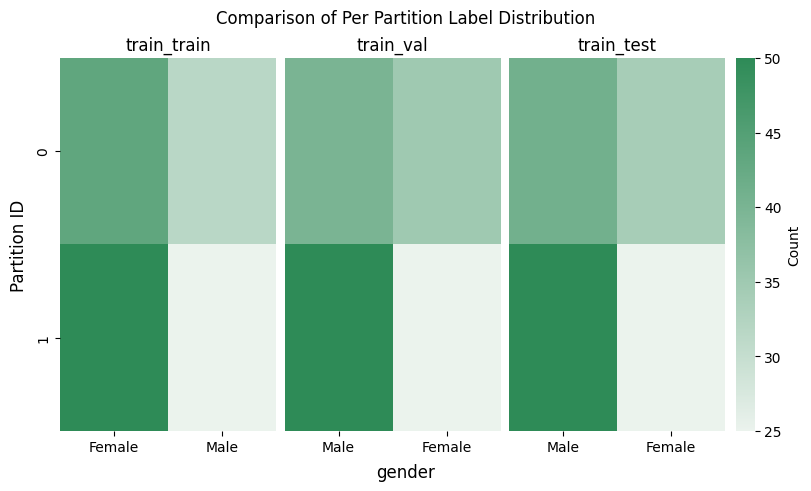

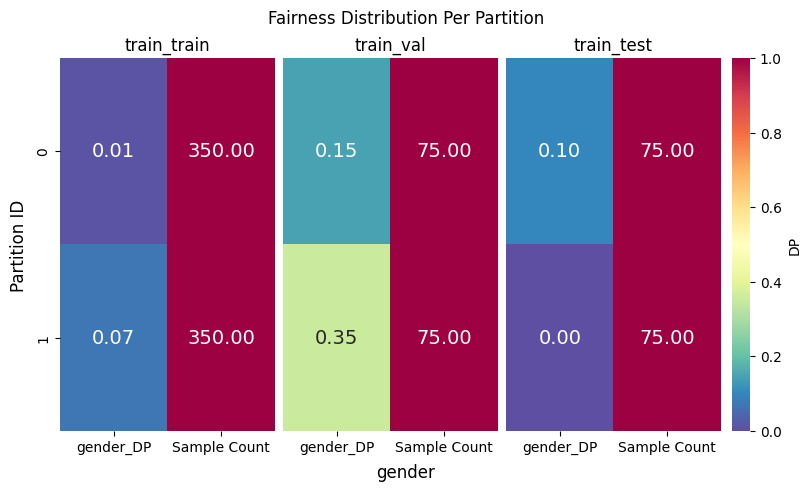

In [8]:
# 5. Evaluate Fairness (optional, if configured)
print("\n5. Evaluating Fairness...")
# Note: Initial evaluation might have run during prepare() if possible.
# We can also run it explicitly.
fds.evaluate()
print("Fairness evaluation completed (check logs/output).")